## Your Group

Submitted by Group 11:

- Ehsan Attar
- Reihaneh Akbarifard
- Name3
- Name4

By submitting this exercise, you confirm the following:

- **All people** listed above **contributed** to this solution
- **No other people** were **involved** in this solution
- **No contents** of this solution were **copied from others** (this includes people, large language models, websites, etc.)

*Put your input image files in `data/input`.*

In [3]:
import sys
print(sys.executable)

import skimage
print(skimage.__version__)

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import blob_log, blob_dog, blob_doh, corner_harris, corner_peaks
np.random.seed(42)
H, W = 256, 256 # Image dimensions

c:\Users\Asus\AppData\Local\Programs\Python\Python313\python.exe
0.26.0


## Helper Functions

In [15]:
def read_image(filename, format='gray'):
    """
    Read image from file and convert to specified format.
    """
    basepath = os.path.curdir
    img = cv2.imread(os.path.join(basepath, 'data', 'input', filename))
    if format == 'gray':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    elif format == 'rgb':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    return img.astype(np.float64)

In [5]:
def make_blob_image(
    radii: list = [4, 8, 16, 32, 64],
    size: int = 256,
    overlap: float = 0.0,
) -> tuple:
    """
    Synthetic black image with white filled circles of given radii.
    Circles are placed left-to-right with controlled spacing.

    Parameters
    ----------
    radii   : list of int — radii of circles to draw
    size    : int         — image is (size x size)
    overlap : float       — fraction of the smaller circle's radius
                           by which adjacent circles may overlap.
                           0.0  = circles just touch (default, no overlap)
                           0.5  = circles overlap by 50% of the smaller radius
                           -0.5 = extra gap equal to 50% of the smaller radius

    Returns
    -------
    img     : np.ndarray (size, size, uint8)
    centres : list of (cx, cy) tuples
    """
    img = np.zeros((size, size), dtype=np.uint8)
    centres = []
    cy = size // 2

    # Place first circle: its left edge starts at one radius from the border
    cx = radii[0] + 5

    for i, r in enumerate(radii):
        centres.append((cx, cy))
        cv2.circle(img, (cx, cy), r, 255, -1)

        if i < len(radii) - 1:
            r_next = radii[i + 1]
            gap = overlap * min(r, r_next)
            # next centre = current centre + current radius + next radius - gap
            cx = cx + r + r_next - int(gap)

    return img, centres

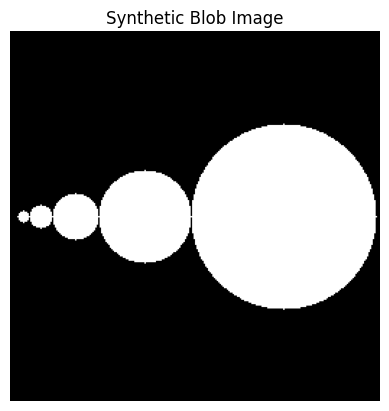

In [6]:
sample_blob_img = make_blob_image(overlap=0.0)
plt.imshow(sample_blob_img[0], cmap='gray'); plt.title('Synthetic Blob Image'); plt.axis('off'); plt.show()

In [7]:
def make_ellipse_image(
    aspect_ratios: list = [2.0, 3.0, 4.0],
    base_radius: int = 40,
    size: int = 256,
    gap_px: int = 5,
    angle: float = 90.0,
) -> tuple:
    """
    Synthetic black image with white filled ellipses of varying aspect ratios.
    Major axis is always base_radius; minor axis = base_radius / aspect_ratio.

    Parameters
    ----------
    aspect_ratios : list of float — major/minor axis ratio.
                    1.0 = circle, 2.0 = twice as wide as tall, etc.
    base_radius   : int   — length of the major axis (semi-axis a) in pixels
    size          : int   — image is (size x size)
    gap_px        : int   — fixed pixel gap between adjacent ellipses
    angle         : float — rotation of all ellipses in degrees (0 = horizontal)

    Returns
    -------
    img     : np.ndarray (size x size, uint8)
    centres : list of (cx, cy) tuples
    axes    : list of (a, b) tuples — (major, minor) semi-axes for each ellipse
    """
    img = np.zeros((size, size), dtype=np.uint8)
    centres = []
    axes_list = []
    cy = size // 2
    cx = base_radius + gap_px   # left margin for first ellipse

    for i, ar in enumerate(aspect_ratios):
        a = base_radius                     # major semi-axis (horizontal)
        b = max(1, int(base_radius / ar))   # minor semi-axis (vertical)

        centres.append((cx, cy))
        axes_list.append((a, b))
        cv2.ellipse(img, (cx, cy), (a, b), angle, 0, 360, 255, -1)

        if i < len(aspect_ratios) - 1:
            # next centre clears current major axis + next major axis + gap
            cx = cx + a + base_radius + gap_px

    return img, centres, axes_list

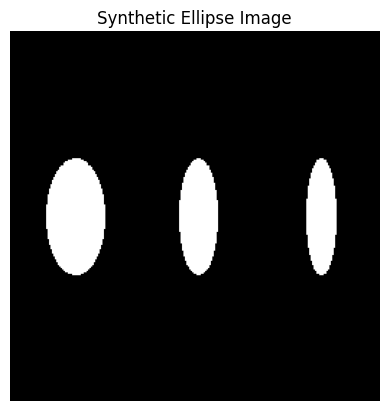

In [8]:
sample_ellipse_img = make_ellipse_image()
plt.imshow(sample_ellipse_img[0], cmap='gray'); plt.title('Synthetic Ellipse Image'); plt.axis('off'); plt.show()

In [9]:
def rotate_image(image: np.ndarray, angle_deg: float) -> np.ndarray:
    """Rotate image about its centre. Empty regions are filled with black."""
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    return cv2.warpAffine(image, M, (w, h))

In [10]:
def plot_1d(signals, labels=None, title=None, xlabel='Pixel', ylabel='Intensity', figsize=(10, 3.5)):
    labels = list(labels or []) + [f"Signal {i+1}" for i in range(len(labels or []), len(signals))]
    fig, ax = plt.subplots(figsize=figsize)
    for signal, label in zip(signals, labels):
        ax.plot(signal, label=label, linewidth=1.5)
    ax.set_title(title or '', fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return fig, ax

## Question 1: Edge Detection

### (1a) Compute and visualise image gradients manually

1. Use `cv2.filter2D()` and the Sobel kernels $S_x \text{ and } S_y$ defined explicitly as NumPy arrays **(do not use `cv2.Sobel()` directly** — define the kernels yourself), and apply both to a greyscale image (any image of your choice).

2. Compute:
* Gradient components $G_x$ and $G_y$ at each pixel
* Gradient magnitude $\mid G \mid$ at each pixel
* Gradient orientation $\theta$ at each pixel

3. Visualise all four outputs. Use cmap='hsv' for the direction map so angular values are visually distinct. 

4. What do you notice about where the magnitude is large vs. where the direction is meaningful?

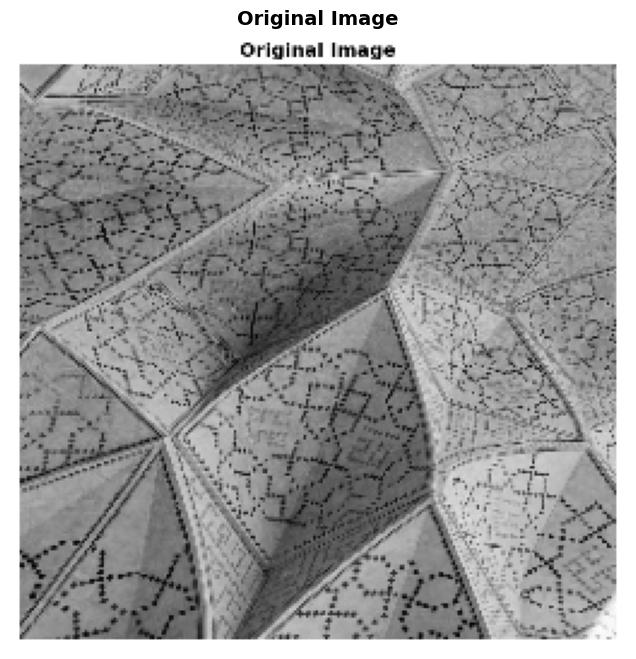

In [11]:
img = read_image('pexels-hossein-monzavizadeh-487831360-15945484.jpg', format='gray')

plt.figure(figsize=(10, 8))
plt.imshow(img, cmap='gray')
plt.title('Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

In [12]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],
                    [0,  0,  0],
                    [1,  2,  1]], dtype=np.float32)

G_x = cv2.filter2D(img, -1, sobel_x)
G_y = cv2.filter2D(img, -1, sobel_y)

magnitude = np.hypot(G_x, G_y)
orientation = np.arctan2(G_y, G_x)
orientation_degrees = np.degrees(orientation)
magnitude_normalized = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())
orientation_normalized = (orientation_degrees + 180) / 360

FileNotFoundError: [Errno 2] No such file or directory: 'data/output/img_gradient_analysis.png'

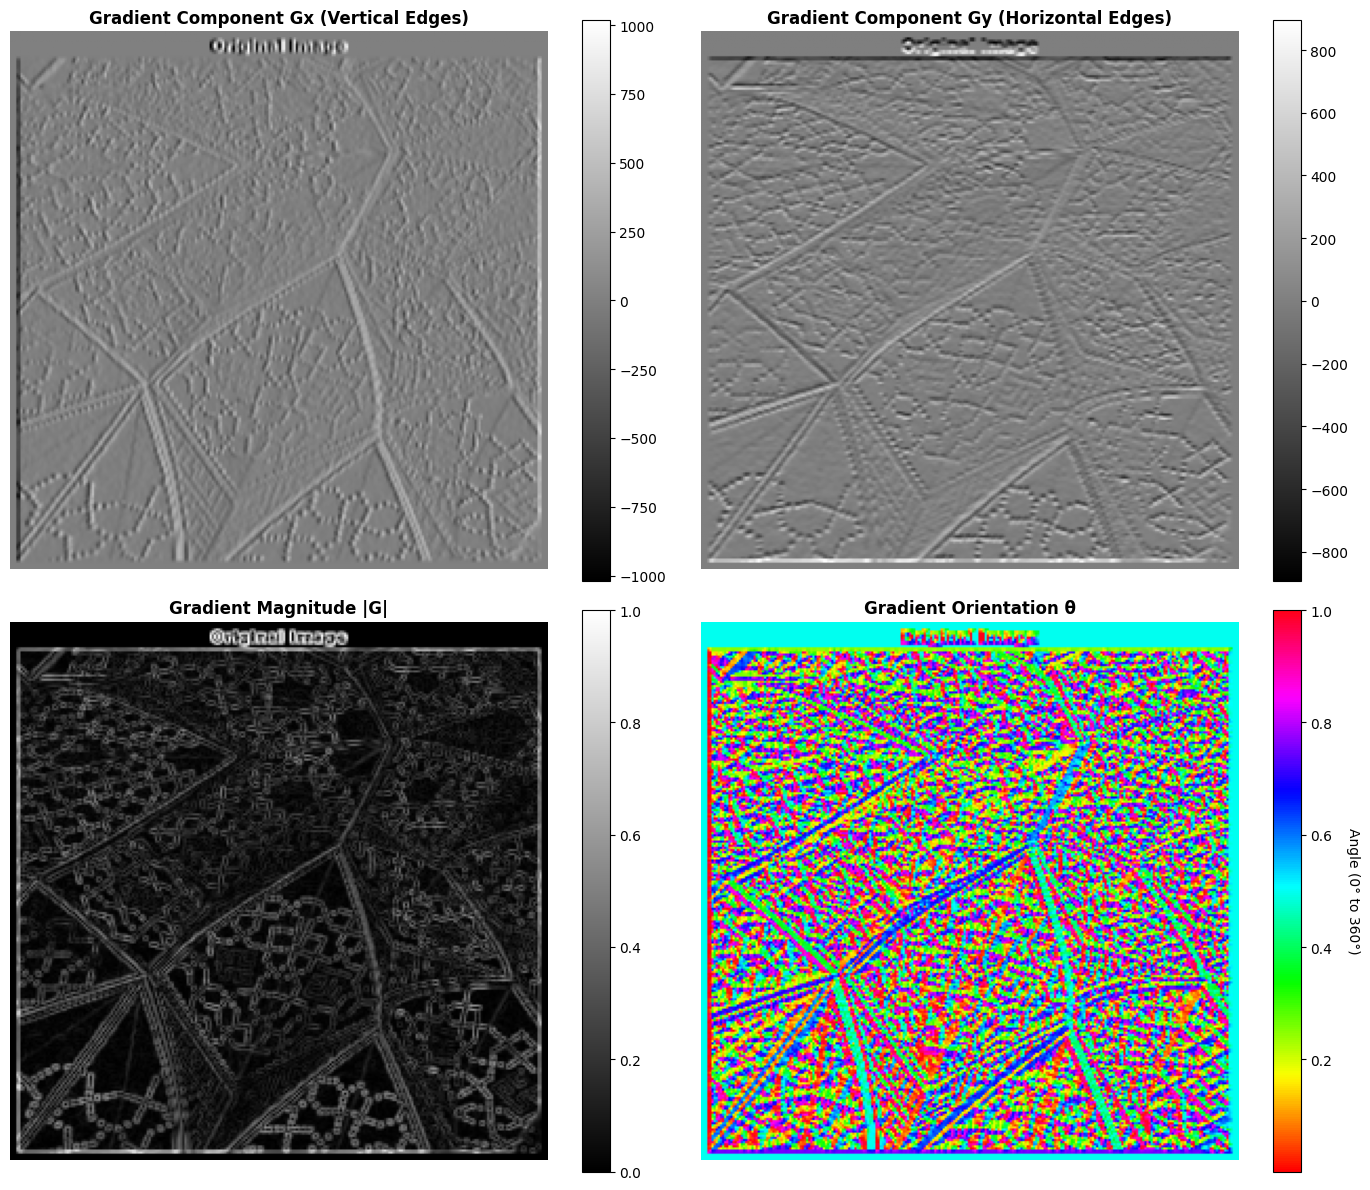

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax = axes[0, 0]
img1 = ax.imshow(G_x, cmap='gray')
ax.set_title('Gradient Component Gx (Vertical Edges)', fontsize=12, fontweight='bold')
ax.axis('off')
plt.colorbar(img1, ax=ax)

ax = axes[0, 1]
img2 = ax.imshow(G_y, cmap='gray')
ax.set_title('Gradient Component Gy (Horizontal Edges)', fontsize=12, fontweight='bold')
ax.axis('off')
plt.colorbar(img2, ax=ax)

ax = axes[1, 0]
img3 = ax.imshow(magnitude_normalized, cmap='gray')
ax.set_title('Gradient Magnitude |G|', fontsize=12, fontweight='bold')
ax.axis('off')
plt.colorbar(img3, ax=ax)

ax = axes[1, 1]
img4 = ax.imshow(orientation_normalized, cmap='hsv')
ax.set_title('Gradient Orientation θ', fontsize=12, fontweight='bold')
ax.axis('off')
cbar = plt.colorbar(img4, ax=ax)
cbar.set_label('Angle (0° to 360°)', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig('data/output/img_gradient_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Magnitude is Large at:

* Object boundaries (face outline, ears, whiskers)
* High-contrast features (eyes, nose, mouth)
* Corners and structural edges

Direction is Meaningful at:

* Exactly where magnitude is large (strong edges)
* Shows organized, consistent color patterns
* Indiimges perpendicular orientation of edges

### (1b) Noise sensitivity of Derivatives

1. Derivatives amplify noise. Verify this by:

* Adding Gaussian noise $(\sigma_{noise}=15)$ to your image
* Computing gradient magnitude on the noisy image without any pre-smoothing
* Computing gradient magnitude *with* Gaussian pre-smoothing at three different scales

2. Plot the gradient magnitude cross-section through a known edge for all four cases using `plot_1d()`. 

3. How does increasing $\sigma$ affect: (a) the noise in the gradient, and (b) the sharpness and position of the edge response? What is the fundamental trade-off being made here?


In [ ]:
sigma_noise = 15
noise = np.random.normal(0, sigma_noise, img.shape)
noisy_img = img + noise

plt.figure(figsize=(10, 8))
plt.imshow(noisy_img, cmap='gray')
plt.title('Original Image', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

G_x_noisy = np.gradient(noisy_img, axis=1)
G_y_noisy = np.gradient(noisy_img, axis=0)
magnitude_noisy = np.hypot(G_x_noisy, G_y_noisy)

G_x_original = np.gradient(img, axis=1)
G_y_original = np.gradient(img, axis=0)
magnitude_original = np.hypot(G_x_original, G_y_original)

smoothing_scales = [1, 3, 6]
magnitudes_smoothed = []
for sigma in smoothing_scales:
    smoothed_img = cv2.GaussianBlur(img, (0, 0), sigma)
    G_x_smoothed = np.gradient(smoothed_img, axis=1)
    G_y_smoothed = np.gradient(smoothed_img, axis=0)
    magnitudes_smoothed.append(np.hypot(G_x_smoothed, G_y_smoothed))

magnitude_strength_per_row = np.max(magnitude_original, axis=1)
row = np.argmax(magnitude_strength_per_row)

signals = [magnitude_noisy[row, :]] + [magnitude[row, :] for magnitude in magnitudes_smoothed]
labels = ['No smoothing'] + [f'σ={s}' for s in smoothing_scales]

plot_1d(signals, labels=labels, title=f'1D Cross-Section: Gradient Magnitude Through Strongest Edge (Row {row})',
    xlabel='Pixel Position', ylabel='Gradient Magnitude', figsize=(12, 5))

### (1c) Comparing Sobel, LoG, and Canny on noisy images

1. On the previously corrupted image apply three edge detectors:

* Sobel (with Gaussian smoothing)
* Laplacian of Gaussian (LoG)- apply `cv2.Laplacian()` after Gaussian smoothing, then threshold zero-crossings
* Canny (experiment with the sigmas and thresholds to get the best results on your image)

2. Visualise the results. Which produces the cleanest, thinnest edges? Which is most sensitive to noise? Discuss why LoG produces double edges at boundaries while Canny does not.

In [ ]:
#Sobel
sigma_sobel = 1.0
img_smoothed = cv2.GaussianBlur(noisy_img, (0, 0), sigma_sobel)
G_x_sobel = cv2.filter2D(img_smoothed, -1, sobel_x)
G_y_nobel = cv2.filter2D(img_smoothed, -1, sobel_y)
edges_sobel = np.hypot(G_x_sobel, G_y_nobel) > 70

#Laplacian
sigma_LoG = 2.0
smoothed_img = cv2.GaussianBlur(noisy_img, (0, 0), sigma_LoG)
smoothed_img_LoG = cv2.Laplacian(smoothed_img, -1)
peak_response = np.abs(smoothed_img_LoG).max()
threshold = 0.15 * peak_response
edges_log = (np.abs(smoothed_img_LoG) > threshold)

#Canny
sigma_canny = 1.0
smoothed_img_canny = cv2.GaussianBlur(noisy_img, (0, 0), sigma_canny)
noisy_img_uint8 = np.uint8(smoothed_img_canny)
threshold1_canny = 50
threshold2_canny = 150
edges_canny = cv2.Canny(noisy_img_uint8, threshold1_canny, threshold2_canny)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax = axes[0, 0]
ax.imshow(noisy_img, cmap='gray')
ax.set_title('Original Noisy Image', fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[0, 1]
ax.imshow(edges_sobel, cmap='gray')
ax.set_title(f'Sobel Edges (σ={sigma_sobel})',
             fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[1, 0]
ax.imshow(edges_log, cmap='gray')
ax.set_title(f'LoG Zero-Crossing Edges (σ={sigma_LoG})', fontsize=12, fontweight='bold')
ax.axis('off')

ax = axes[1, 1]
ax.imshow(edges_canny, cmap='gray')
ax.set_title(f'Canny Edges (T1={threshold1_canny}, T2={threshold2_canny})',
             fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('data/output/edge_detection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Blob Detection

### (2a) LoG Response

Generate a synthetic image, containing a single row of circle of radius $r \in \{4, 8, 16, 32, 64\}$ on a black background (use the provided method ``make_blob_image()``). 

For each image, compute the LoG response at the circle's centre across $\sigma \in [1, 50]$ sampled at 30 points (use ``blob_log()``) and find the $\sigma$ for each detected blob. Plot the response of the cross-section line along the blob centers for each of the 5 detected scales on the same axes using ``plot_1d()``.

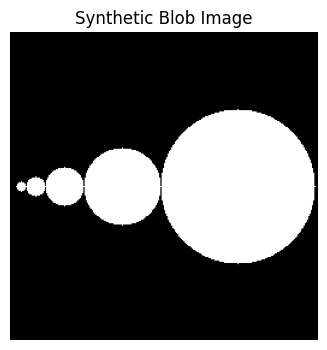

[[128.           8.           2.68965517]
 [128.         181.          44.93103448]
 [128.          42.          11.13793103]
 [128.          87.          22.96551724]
 [128.          19.           6.06896552]
 [123.          26.           1.        ]
 [133.          26.           1.        ]]


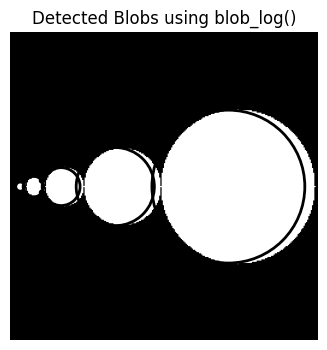

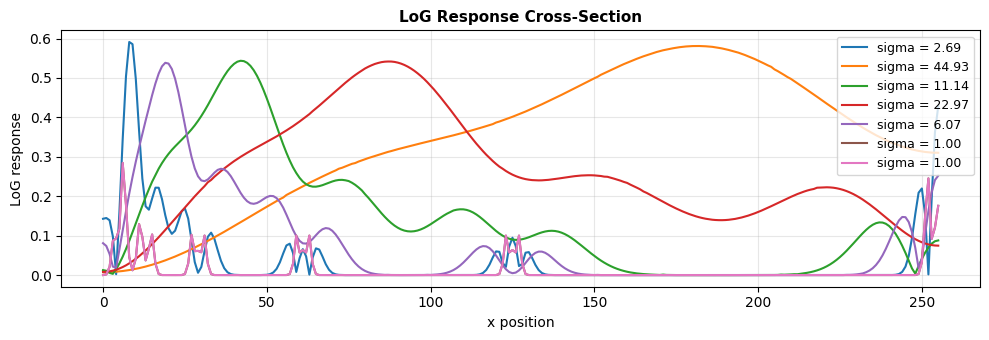

(<Figure size 1000x350 with 1 Axes>,
 <Axes: title={'center': 'LoG Response Cross-Section'}, xlabel='x position', ylabel='LoG response'>)

In [ ]:
radii = [4, 8, 16, 32, 64]

img, centers = make_blob_image(
    radii=radii,
    size=256,
    overlap=0.0
)

plt.figure(figsize=(8, 4))
plt.imshow(img, cmap='gray')
plt.title("Synthetic Blob Image")
plt.axis("off")
plt.show()

#this algorithm works better with float numbers
img_float = img.astype(np.float64) / 255.0

#using different sigmas to detect the blobs
#the output contains the positions of detected blobs and their sigma values
blobs = blob_log(
    img_float,
    min_sigma=1,
    max_sigma=50,
    num_sigma=30,
    threshold=0.3)

print(blobs)


fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(img, cmap='gray')
ax.set_title("Detected Blobs using blob_log()")
ax.axis("off")

#convert sigma to approximate radius and draw circles
for y, x, sigma in blobs:
    detected_radius = np.sqrt(2) * sigma
    circle = plt.Circle((x, y), detected_radius, fill=False, linewidth=2)
    ax.add_patch(circle)

plt.show()

#LoG response cross-section

signals = []
labels = []

center_y = img.shape[0] // 2

for y, x, sigma in blobs:
    blurred = cv2.GaussianBlur(
        img_float,
        ksize=(0, 0),
        sigmaX=sigma,
        sigmaY=sigma
    )

    log_response = cv2.Laplacian(blurred, cv2.CV_64F)

    normalized_response = (sigma ** 2) * np.abs(log_response)

    line_response = normalized_response[center_y, :]

    signals.append(line_response)
    labels.append(f"sigma = {sigma:.2f}")

plot_1d(
    signals,
    labels=labels,
    title="LoG Response Cross-Section",
    xlabel="x position",
    ylabel="LoG response"
)

### (2b) Relation between $r$ and $\sigma_{peak}$

Plot $r \text{ vs. } \sigma_{peak}$ and fit a line through the origin. What is the slope? The theory predicts $r = \sqrt{2}\,\sigma_{peak}$.

Total blobs detected: 41
Blobs (row, col, sigma):
[[128.           8.           2.68965517]
 [128.         181.          44.93103448]
 [128.          42.          11.13793103]
 [128.          87.          22.96551724]
 [128.          19.           6.06896552]
 [123.          26.           1.        ]
 [133.          26.           1.        ]
 [116.          54.           1.        ]
 [140.          54.           1.        ]
 [102.         110.           1.        ]
 [154.         110.           1.        ]
 [ 91.         240.           1.        ]
 [165.         240.           1.        ]
 [ 77.         226.           1.        ]
 [179.         226.           1.        ]
 [ 75.         223.           1.        ]
 [181.         223.           1.        ]
 [107.         114.           2.68965517]
 [149.         114.           2.68965517]
 [101.         240.           6.06896552]
 [155.         240.           6.06896552]
 [ 73.         216.           2.68965517]
 [183.         216.       

Text(0.5, 0, 'σ_peak')

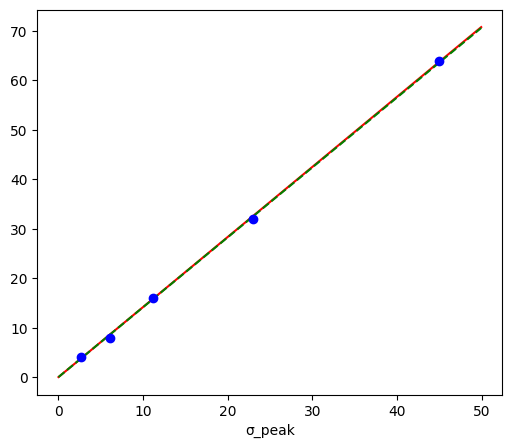

In [ ]:
# --- Step 1: Generate synthetic blob image ---
radii_true = [4, 8, 16, 32, 64]
blob_img, centres = make_blob_image(radii=radii_true, overlap=0.0)

# --- Step 2: Detect blobs using blob_log ---
blobs = blob_log(
    blob_img,
    min_sigma=1,
    max_sigma=50,
    num_sigma=30,
    threshold=0.05
)
# blobs columns: [row, col, sigma]

print(f"Total blobs detected: {len(blobs)}")
print("Blobs (row, col, sigma):")
print(blobs)

#we used blob_log to detect blobs at different sigma values. Since the true centers of the circles are known,
#we matched each true circle with the closest detected blob and saved its sigma value as sigma_peak.

#For each true centre, find the closest detected blob 
sigma_peaks = []
for (cx, cy) in centres:
    # centres are (x=col, y=row), blobs are (row, col, sigma)
    dists = np.sqrt((blobs[:, 0] - cy)**2 + (blobs[:, 1] - cx)**2)
    closest_idx = np.argmin(dists)
    sigma_peaks.append(blobs[closest_idx, 2])
    print(f"  True centre ({cx},{cy}), closest blob at dist={dists[closest_idx]:.1f}, sigma={blobs[closest_idx,2]:.2f}")

sigma_peaks = np.array(sigma_peaks)
radii_arr = np.array(radii_true)

#Fit a line through the origin 
m = np.dot(radii_arr, sigma_peaks) / np.dot(sigma_peaks, sigma_peaks)
print(f"\nFitted slope m = {m:.4f}")
print(f"Theoretical slope sqrt(2) = {np.sqrt(2):.4f}")

sigma_line = np.linspace(0, max(sigma_peaks) + 5, 100)

plt.figure(figsize=(6, 5))
plt.scatter(sigma_peaks, radii_arr, color='blue', zorder=5, label='Detected blobs')
plt.plot(sigma_line, m * sigma_line, 'r-', label=f'Fitted: r = {m:.3f}·σ')
plt.plot(sigma_line, np.sqrt(2) * sigma_line, 'g--', label=r'Theory: r = $\sqrt{2}$·σ')
plt.xlabel('σ_peak')

### (2c) Response to Elliptical Blobs

Now test with non-circular blobs: generate ellipses of varying aspect ratios:  $\{1:1,\ 2:1,\ 3:1\}$ using ``make_ellipse_image()``. What $\sigma$ does ``blob_log()`` report for an ellipse? Using $r = \sqrt{2}\,\sigma_{peak}$ is $r$ closer to its major axis length, minor axis length, or their geometric mean? Run the experiment and compare for the diff aspect ratios.

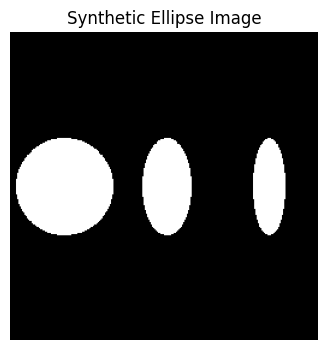

All detected ellipse blobs:
[[128.          46.          26.34482759]
 [128.         131.          19.5862069 ]
 [122.         215.          14.51724138]
 [152.         215.           9.44827586]
 [ 98.          19.           1.        ]
 [ 91.         123.           1.        ]
 [ 91.         137.           1.        ]
 [ 94.         120.           1.        ]
 [ 94.         140.           1.        ]
 [158.          19.           1.        ]
 [ 88.         215.           1.        ]
 [168.         215.           1.        ]
 [ 98.          71.           1.        ]
 [154.          15.           1.        ]
 [165.         123.           1.        ]
 [161.         119.           1.        ]
 [161.         141.           1.        ]
 [165.         137.           1.        ]
 [154.          75.           1.        ]
 [158.          71.           1.        ]
 [ 94.         209.           1.        ]
 [ 94.         221.           1.        ]
 [ 97.         118.           1.        ]
 [ 97.

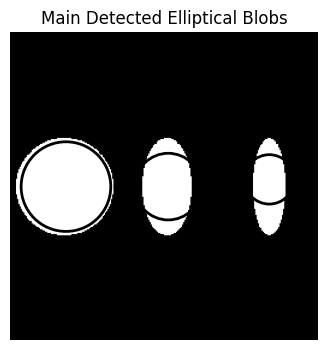


Ellipse 1
Major axis (a): 40
Minor axis (b): 40
Detected radius: 37.26
Geometric mean sqrt(a*b): 40.00

Ellipse 2
Major axis (a): 40
Minor axis (b): 20
Detected radius: 27.70
Geometric mean sqrt(a*b): 28.28

Ellipse 3
Major axis (a): 40
Minor axis (b): 13
Detected radius: 20.53
Geometric mean sqrt(a*b): 22.80


In [ ]:

aspect_ratios = [1, 2, 3]

#create ellipse image using the provided helper
ellipse_img, ellipse_centres, axes = make_ellipse_image(
    aspect_ratios=aspect_ratios,
    size=256
)

plt.figure(figsize=(8, 4))
plt.imshow(ellipse_img, cmap="gray")
plt.title("Synthetic Ellipse Image")
plt.axis("off")
plt.show()

#convert image to float
ellipse_float = ellipse_img.astype(np.float64) / 255.0

#detect blobs using blob_log
ellipse_blobs = blob_log(
    ellipse_float,
    min_sigma=1,
    max_sigma=50,
    num_sigma=30,
    threshold=0.15,
    overlap=0.2
)

print("All detected ellipse blobs:")
print(ellipse_blobs)

#keep only one main detection per ellipse
main_ellipse_blobs = []

for (cx, cy) in ellipse_centres:
    dists = np.sqrt(
        (ellipse_blobs[:, 0] - cy) ** 2 +
        (ellipse_blobs[:, 1] - cx) ** 2
    )

    closest_idx = np.argmin(dists)
    main_ellipse_blobs.append(ellipse_blobs[closest_idx])

main_ellipse_blobs = np.array(main_ellipse_blobs)

print("Main ellipse blobs:")
print(main_ellipse_blobs)

#draw only the main detections
fig, ax = plt.subplots(figsize=(8, 4))
ax.imshow(ellipse_img, cmap="gray")
ax.set_title("Main Detected Elliptical Blobs")
ax.axis("off")

for y, x, sigma in main_ellipse_blobs:
    detected_radius = np.sqrt(2) * sigma
    circle = plt.Circle(
        (x, y),
        detected_radius,
        fill=False,
        linewidth=2
    )
    ax.add_patch(circle)

plt.show()



# Compare detected radius with ellipse axes

for i, ((a, b), (_, _, sigma)) in enumerate(zip(axes, main_ellipse_blobs)):

    detected_radius = np.sqrt(2) * sigma

    geometric_mean = np.sqrt(a * b)

    print(f"\nEllipse {i+1}")

    print(f"Major axis (a): {a}")

    print(f"Minor axis (b): {b}")

    print(f"Detected radius: {detected_radius:.2f}")

    print(f"Geometric mean sqrt(a*b): {geometric_mean:.2f}")

### (2d) Response to Overlapping Blobs

Run ``blob_log()`` on three blob images with varying overlap (generate with `make_blob_image()`) at two overlap tolerance levels: overlap=0.0 (no overlapping blobs allowed) and overlap=0.8 (blobs may overlap significantly). Visualise both. How many blobs does each setting return? When would you want a high overlap tolerance in practice?

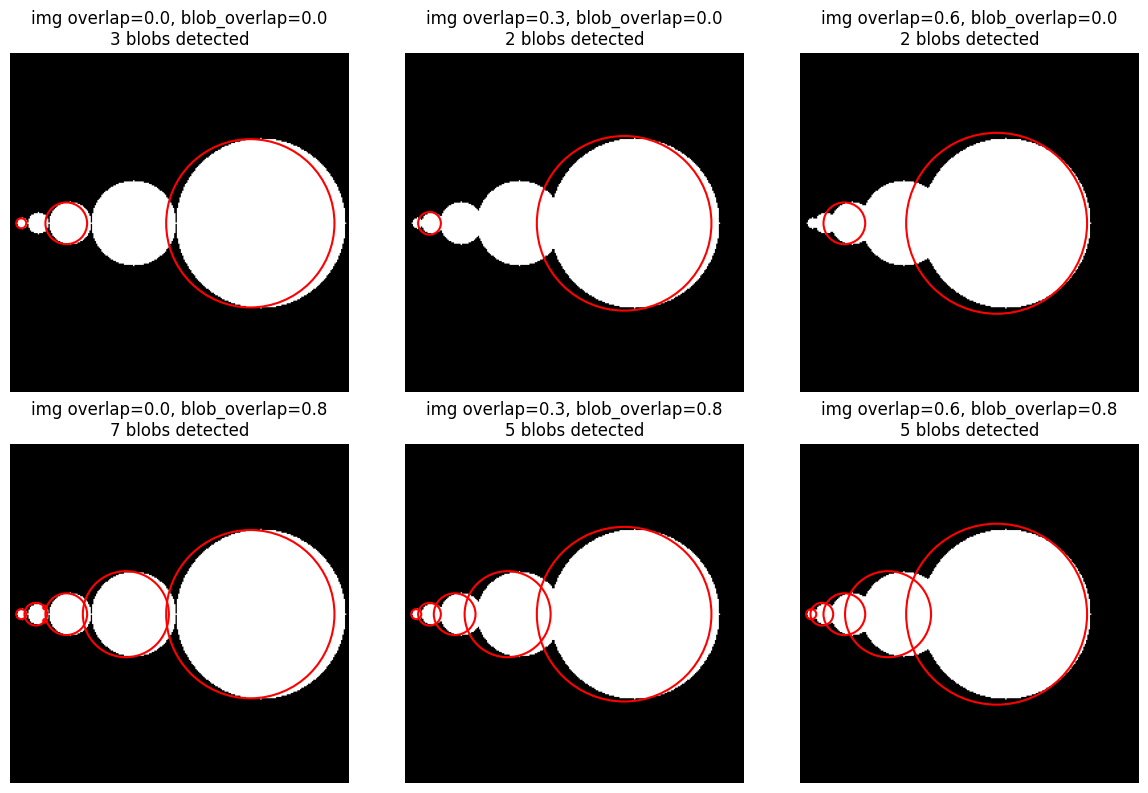

In [ ]:
#Generate 3 blob images with varying overlap
overlap_values = [0.0, 0.3, 0.6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for col, ov in enumerate(overlap_values):
    img, centres = make_blob_image(radii=[4, 8, 16, 32, 64], overlap=ov)
    
    for row, blob_overlap in enumerate([0.0, 0.8]):
        blobs = blob_log(
            img,
            min_sigma=1,
            max_sigma=50,
            num_sigma=30,
            threshold=0.3,
            overlap=blob_overlap
        )
        
        ax = axes[row, col]
        ax.imshow(img, cmap='gray')
        for blob in blobs:
            y, x, sigma = blob
            r = np.sqrt(2) * sigma
            circle = plt.Circle((x, y), r, color='red', fill=False, linewidth=1.5)
            ax.add_patch(circle)
        ax.set_title(f'img overlap={ov}, blob_overlap={blob_overlap}\n{len(blobs)} blobs detected')
        ax.axis('off')

plt.tight_layout()
plt.show()

### (2e) LoG vs DoH

The `blob_doh()` detector does not use scale-normalised responses- it uses the determinant of the Hessian matrix directly. This makes it very fast but changes its behaviour. Run `blob_doh()` and `blob_log()` on the same natural image (any image of your choice) and compare: which finds larger blobs more reliably? Which is better for small blobs?

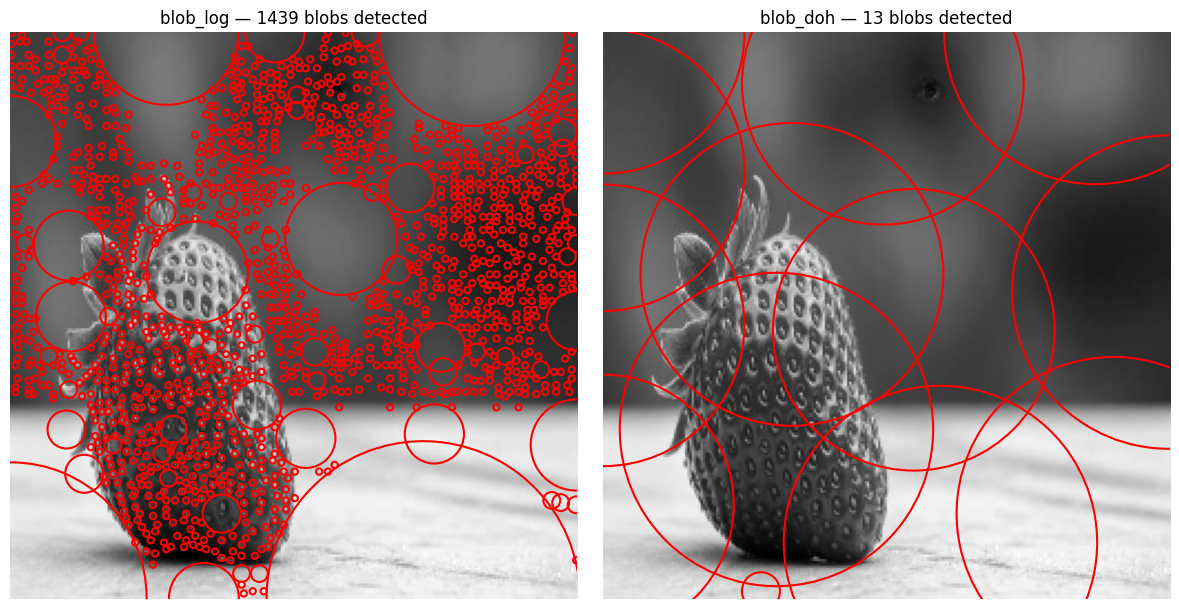

In [17]:
#Load a natural image
img_natural = read_image('../input/image.jpg')

#Run blob_log
blobs_log = blob_log(
    img_natural,
    min_sigma=1,
    max_sigma=50,
    num_sigma=30,
    threshold=0.1
)

#Run blob_doh
blobs_doh = blob_doh(
    img_natural,
    min_sigma=1,
    max_sigma=50,
    num_sigma=30,
    threshold=0.001
)

#Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, blobs, title in zip(axes, [blobs_log, blobs_doh], ['blob_log', 'blob_doh']):
    ax.imshow(img_natural, cmap='gray')
    for blob in blobs:
        y, x, sigma = blob
        r = np.sqrt(2) * sigma
        circle = plt.Circle((x, y), r, color='red', fill=False, linewidth=1.5)
        ax.add_patch(circle)
    ax.set_title(f'{title} — {len(blobs)} blobs detected')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Corner Detection

### Note for Question 3
The code for Questions 1 and 2 above is kept from the group notebook. The following cells complete Question 3. Make sure the image used in Question 1 has already been loaded into the variable `img`.


In [ ]:
# Extra import needed for Question 3(e)
from skimage.feature import corner_shi_tomasi


### (3a) The Harris response map R

Compute the Harris corner response using `corner_harris()` on a grayscale image (any image of your choice). Visualise the full raw $R$ map. From the lecture, $R$ has three regimes.

Identify one example of each regime in your image. Crop and show those three patches side by side with their mean $R$ values as titles.

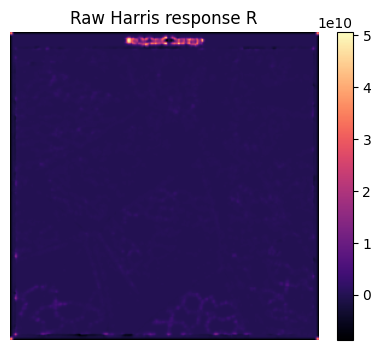

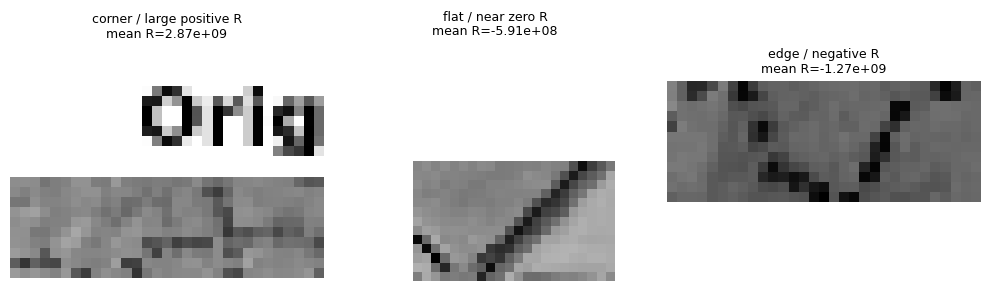

In [ ]:
img_normalized=img.astype(np.float32)
R = corner_harris(img_normalized, method='k', k=0.05, sigma=1)
plt.figure(figsize=(5, 4)); 
plt.imshow(R, cmap='magma'); 
plt.colorbar(); 
plt.title('Raw Harris response R'); 
plt.axis('off'); 
plt.show()

# Pick representative patches: corner (large +R), flat (near zero), edge (negative R).
coords = {
    'corner / large positive R': np.unravel_index(np.argmax(R), R.shape),
    'flat / near zero R': (10, 10),
    'edge / negative R': np.unravel_index(np.argmin(R), R.shape)
}
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
for i, (name, (yy, xx)) in zip(ax, coords.items()):
    y0, y1 = max(0, yy-15), min(R.shape[0], yy+16)
    x0, x1 = max(0, xx-15), min(R.shape[1], xx+16)
    patch = img[y0:y1, x0:x1]
    meanR = R[y0:y1, x0:x1].mean()
    i.imshow(patch, cmap='gray')
    i.set_title(f'{name}\nmean R={meanR:.2e}', fontsize=9)
    i.axis('off')
plt.tight_layout(); 
plt.show()

**Answer.** Harris responses separate into three regimes: flat regions have response near zero, edges have one dominant gradient direction and often negative response, and corners have two strong orthogonal gradient directions and large positive response.

### (3b) Extracting corners — threshold and spatial suppression

Use `corner_peaks()` to extract corner coordinates from the Harris $R$ map. Sweep two parameters independently:

* `threshold_rel` $\in \{0.001, 0.01, 0.05, 0.1 \}$ (with fixed min_distance=7)
* `min_distance` $\in \{3, 7, 15, 30 \}$ (with fixed threshold_rel=0.02)

For each sweep, draw detected point on the image and show the results. Plot corner count vs each parameter using `plot_1d()`. What is min_distance doing geometrically?

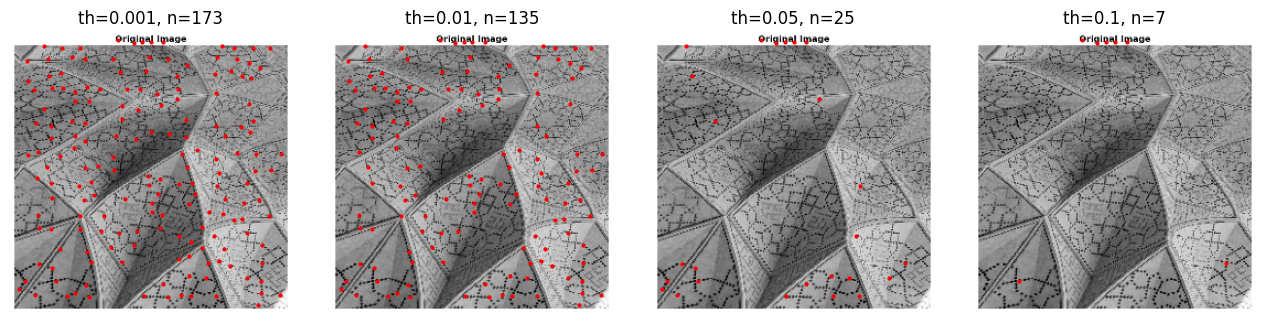

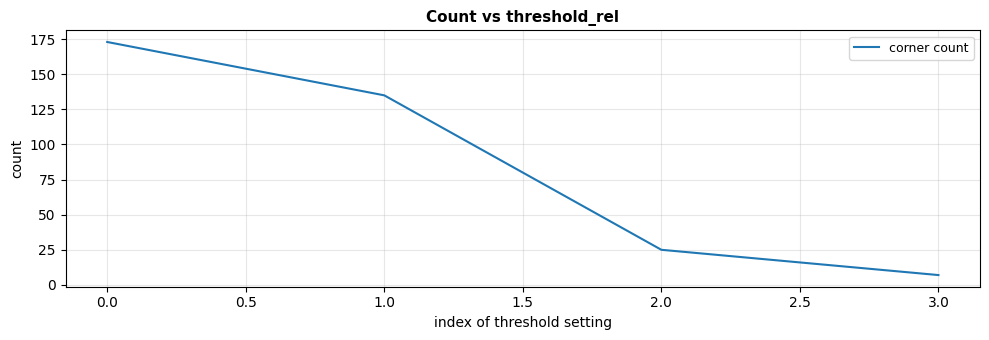

thresholds: [0.001, 0.01, 0.05, 0.1]
counts: [173, 135, 25, 7]


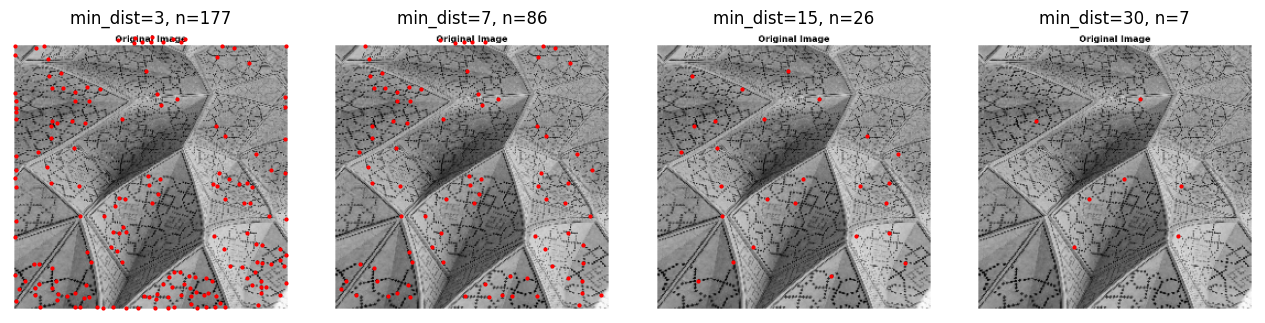

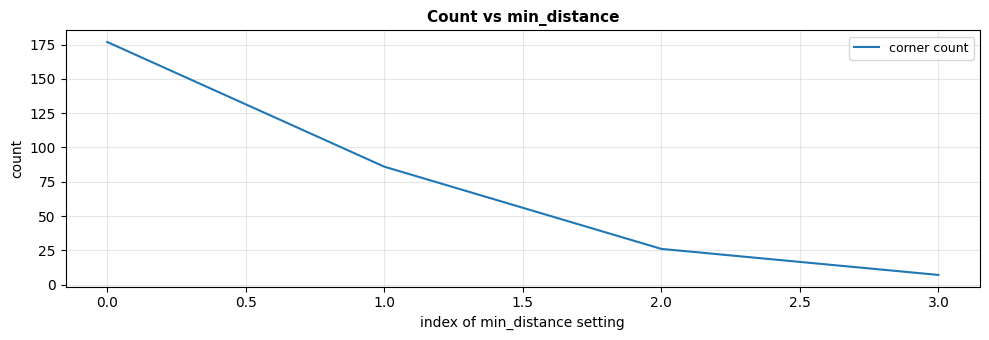

min_distance values: [3, 7, 15, 30]
counts: [177, 86, 26, 7]


In [ ]:
def draw_corners(base, coords, title):
    plt.figure(figsize=(4,4))
    plt.imshow(base, cmap='gray')
    if len(coords):
        plt.plot(coords[:,1], coords[:,0], 'r.', markersize=5)
    plt.title(title + f' (n={len(coords)})')
    plt.axis('off'); 
    plt.show()

thresholds = [0.001, 0.01, 0.05, 0.1]
th_counts = []
fig, ax = plt.subplots(1, 4, figsize=(13,3.2))
for a, tr in zip(ax, thresholds):
    coords = corner_peaks(R, threshold_rel=tr, min_distance=7)
    th_counts.append(len(coords))
    a.imshow(img, cmap='gray'); 
    a.plot(coords[:,1], coords[:,0], 'r.', markersize=4)
    a.set_title(f'th={tr}, n={len(coords)}'); 
    a.axis('off')
plt.tight_layout(); 
plt.show()
plot_1d([th_counts], labels=['corner count'], title='Count vs threshold_rel', xlabel='index of threshold setting', ylabel='count')
print('thresholds:', thresholds)
print('counts:', th_counts)

min_dists = [3, 7, 15, 30]
md_counts = []
fig, ax = plt.subplots(1, 4, figsize=(13,3.2))
for a, md in zip(ax, min_dists):
    coords = corner_peaks(R, threshold_rel=0.02, min_distance=md)
    md_counts.append(len(coords))
    a.imshow(img, cmap='gray'); 
    a.plot(coords[:,1], coords[:,0], 'r.', markersize=4)
    a.set_title(f'min_dist={md}, n={len(coords)}'); 
    a.axis('off')
plt.tight_layout(); 
plt.show()
plot_1d([md_counts], labels=['corner count'], title='Count vs min_distance', xlabel='index of min_distance setting', ylabel='count')
print('min_distance values:', min_dists)
print('counts:', md_counts)

**Answer.** Increasing `threshold_rel` removes weaker corners, so the count decreases. Increasing `min_distance` enforces a larger spatial exclusion radius between peaks, so nearby corner candidates are suppressed. Geometrically, `min_distance` is a non-maximum-suppression radius in image coordinates.

### (3c) Harris is rotation-invariant

Rotate your image by $\{30°, 60°, 90°\}$ using the provided ``rotate_image()`` helper. Run ``corner_harris()`` + ``corner_peaks()`` (with fixed parameters) on the original and all three rotated versions. Report the corner count for each and visualise detections.

Does the count stay roughly constant across rotations? Explain from the definition $R = \det(H) - k(\text{trace}\,H)^2$ why rotation does not change $R$. 

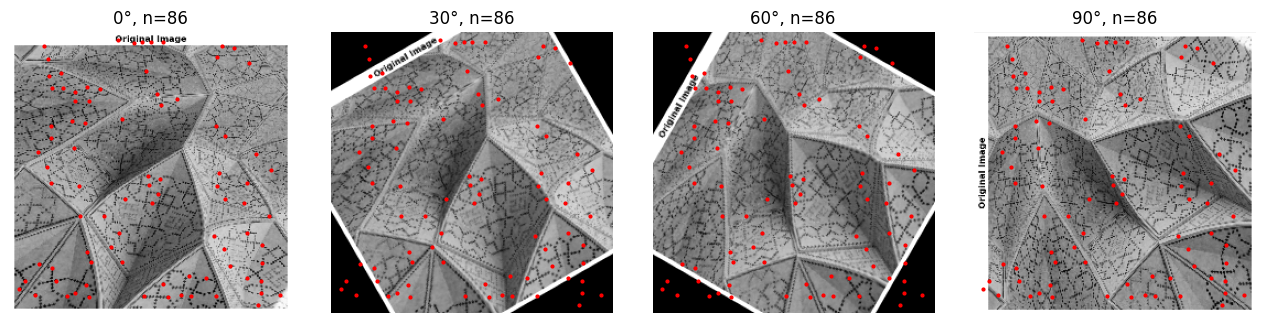

{0: 86, 30: 86, 60: 86, 90: 86}


In [ ]:
angles = [0, 30, 60, 90]
rot_counts = []
fig, ax = plt.subplots(1, 4, figsize=(13,3.2))
for a, ang in zip(ax, angles):
    image_r = img if ang == 0 else rotate_image(img, ang)
    img_normalized=img.astype(np.float32)
    Rr = corner_harris(img_normalized, method='k', k=0.05, sigma=1)
    coords = corner_peaks(Rr, threshold_rel=0.02, min_distance=7)
    rot_counts.append(len(coords))
    a.imshow(image_r, cmap='gray'); a.plot(coords[:,1], coords[:,0], 'r.', markersize=4)
    a.set_title(f'{ang}°, n={len(coords)}'); a.axis('off')
plt.tight_layout(); plt.show()
print(dict(zip(angles, rot_counts)))

**Answer.** The count should remain roughly similar under rotation, although not exactly identical because interpolation and cropping change pixels near boundaries. The Harris score depends on \(\det(H)\) and \(\operatorname{trace}(H)\). These quantities are invariant under rotation of the coordinate axes, so the response is theoretically rotation-invariant.

### (3d) Effect of Scale

Resize your image to scales \{0.5\times, 0.75\times, 1.0\times, 1.5\times\} using ``cv2.resize()``. Run ``corner_harris()`` + ``corner_peaks()`` with the same fixed parameters on each. Report and plot corner counts vs scale. Then on the $0.5\times$ image, double the sigma parameter of corner_harris to compensate- what happens to the count? 

Why does Harris fail under scale change despite being rotation-invariant, and what would be needed to make it truly scale-invariant?

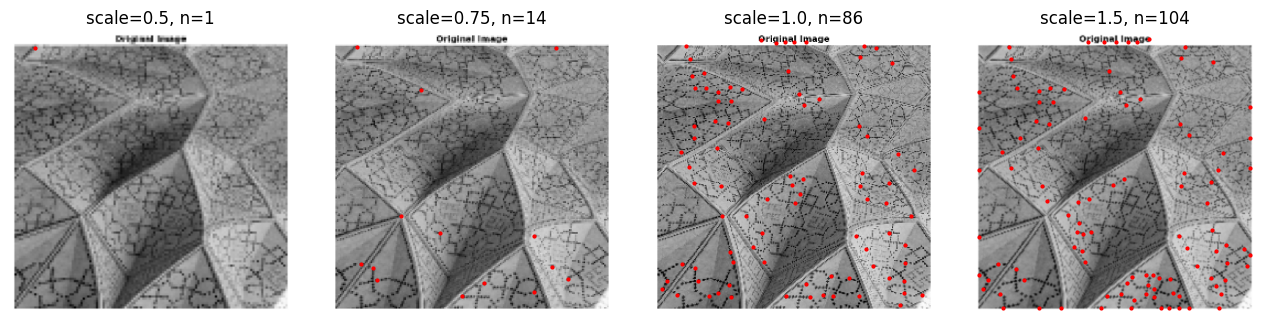

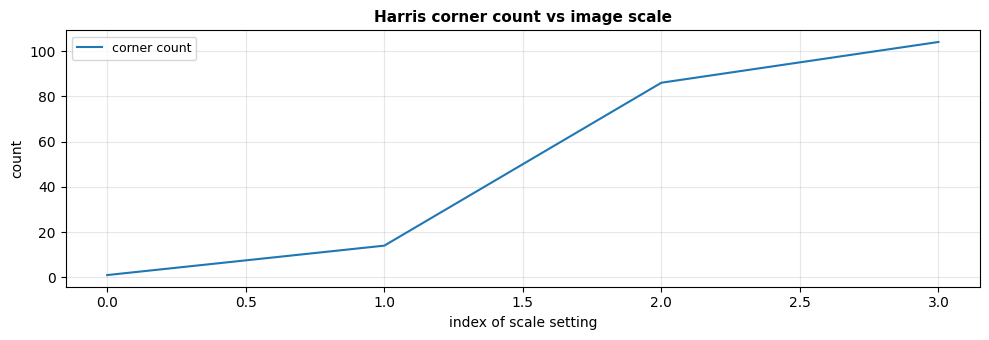

scales: [0.5, 0.75, 1.0, 1.5]
counts: [1, 14, 86, 104]
0.5x image, sigma=1 count: 1
0.5x image, sigma=2 count: 0


In [ ]:
scales = [0.5, 0.75, 1.0, 1.5]
scale_counts = []
fig, ax = plt.subplots(1, 4, figsize=(13,3.2))
for a, sc in zip(ax, scales):
    resized = cv2.resize(img, None, fx=sc, fy=sc, interpolation=cv2.INTER_LINEAR)
    Rsc = corner_harris(resized / 255.0, method='k', k=0.05, sigma=1)
    coords = corner_peaks(Rsc, threshold_rel=0.02, min_distance=7)
    scale_counts.append(len(coords))
    a.imshow(resized, cmap='gray'); a.plot(coords[:,1], coords[:,0], 'r.', markersize=4)
    a.set_title(f'scale={sc}, n={len(coords)}'); a.axis('off')
plt.tight_layout(); plt.show()
plot_1d([scale_counts], labels=['corner count'], title='Harris corner count vs image scale', xlabel='index of scale setting', ylabel='count')
print('scales:', scales)
print('counts:', scale_counts)

small = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)
R_small_1 = corner_harris(small / 255.0, method='k', k=0.05, sigma=1)
R_small_2 = corner_harris(small / 255.0, method='k', k=0.05, sigma=2)
c1 = corner_peaks(R_small_1, threshold_rel=0.02, min_distance=7)
c2 = corner_peaks(R_small_2, threshold_rel=0.02, min_distance=7)
print(f'0.5x image, sigma=1 count: {len(c1)}')
print(f'0.5x image, sigma=2 count: {len(c2)}')

**Answer.** Harris is not scale-invariant when parameters are fixed in pixels. Resizing changes the apparent size of corner structures relative to the derivative/integration scale and relative to the fixed non-maximum suppression distance. Increasing sigma on the 0.5x image changes the count because it changes the measurement scale, but true scale invariance would require detecting characteristic scale, for example with multi-scale Harris/Harris-Laplace or another scale-space method.

### (3e) Harris vs Shi-Tomasi

Compute both response maps on the same image:

* Harris: ``corner_harris()`` (uses $R = \det(H) - k(\text{trace}\,H)^2$ )
* Shi-Tomasi: ``corner_shi_tomasi()`` (uses $R = \min(\lambda_1, \lambda_2)$)

Visualise both response maps side by side. Extract corners from each with ``corner_peaks()`` using the same ``threshold_rel`` and ``min_distance``, draw them, and report the counts. Do the two methods detect corners at the same locations even though the scores differ?

Is there a scenario where Harris would detect a corner that Shi-Tomasi misses, or vice versa?

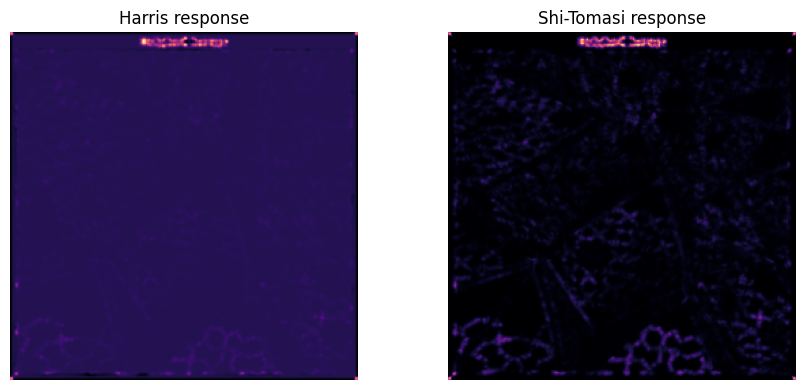

Harris corners: 86
Shi-Tomasi corners: 178


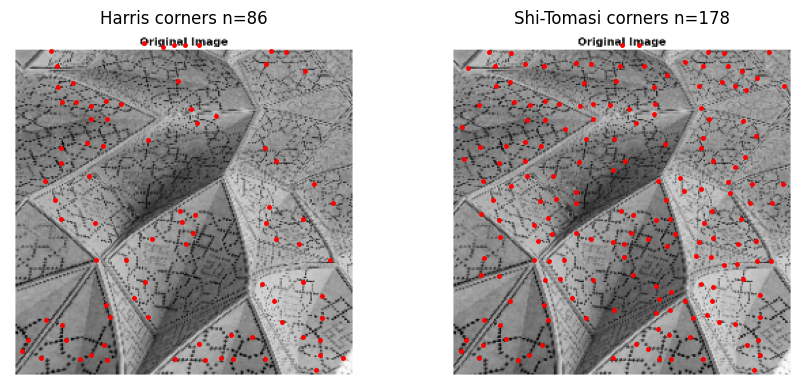

In [18]:
from skimage.feature import corner_harris, corner_peaks, corner_shi_tomasi

R_harris = corner_harris(img / 255.0, method='k', k=0.05, sigma=1)
R_shi = corner_shi_tomasi(img / 255.0, sigma=1)
fig, ax = plt.subplots(1, 2, figsize=(9,4))
ax[0].imshow(R_harris, cmap='magma'); ax[0].set_title('Harris response'); ax[0].axis('off')
ax[1].imshow(R_shi, cmap='magma'); ax[1].set_title('Shi-Tomasi response'); ax[1].axis('off')
plt.tight_layout(); plt.show()

ch = corner_peaks(R_harris, threshold_rel=0.02, min_distance=7)
cs = corner_peaks(R_shi, threshold_rel=0.02, min_distance=7)
print(f'Harris corners: {len(ch)}')
print(f'Shi-Tomasi corners: {len(cs)}')
fig, ax = plt.subplots(1, 2, figsize=(9,4))
for a, coords, title in zip(ax, [ch, cs], ['Harris corners', 'Shi-Tomasi corners']):
    a.imshow(img, cmap='gray')
    a.plot(coords[:,1], coords[:,0], 'r.', markersize=5)
    a.set_title(title + f' n={len(coords)}')
    a.axis('off')
plt.tight_layout(); plt.show()

**Answer.** The two methods usually detect many of the same physical corner locations, but the scores and therefore the final thresholded sets can differ. Harris combines the eigenvalues through \(\det(H)-k\operatorname{trace}(H)^2\), while Shi-Tomasi uses the smaller eigenvalue directly. Shi-Tomasi can reject points where one eigenvalue is not sufficiently strong; Harris may include or exclude points differently depending on the value of \(k\) and thresholding.